In [1]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
import pandas as pd
import os

os.chdir('D:\math1\data')

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\icyw\AppData\Local\Temp\ipykernel_10216\2191946730.py:7: SyntaxWarning: invalid escape sequence '\m'
  os.chdir('D:\math1\data')


In [7]:
sheet_names = ['2015', '2016', '2017', '2018', '会员等级']
sheet_dict = pd.read_excel('sales.xlsx', sheet_name=sheet_names)
#从excel中读取文件，获取字典形式 每张表名对应不同的dataframe

In [8]:
sheet_dict

{'2015':               会员ID         订单号       提交日期    订单金额
 0      15278002468  3000304681 2015-01-01   499.0
 1      39236378972  3000305791 2015-01-01  2588.0
 2      38722039578  3000641787 2015-01-01   498.0
 3      11049640063  3000798913 2015-01-01  1572.0
 4      35038752292  3000821546 2015-01-01    10.1
 ...            ...         ...        ...     ...
 30769  39368100847  4281994827 2015-12-31   828.0
 30770       409757  4282010457 2015-12-31   199.0
 30771  38380526114  4282017675 2015-12-31   208.0
 30772     28074988  4282019440 2015-12-31    89.0
 30773  39460363230  4282025309 2015-12-31   719.0
 
 [30774 rows x 4 columns],
 '2016':               会员ID         订单号       提交日期     订单金额
 0      39288120141  4282025766 2016-01-01    76.00
 1      39293812118  4282037929 2016-01-01  7599.00
 2      27596340905  4282038740 2016-01-01   802.00
 3      15111475509  4282043819 2016-01-01    65.00
 4      38896594001  4282051044 2016-01-01    95.00
 ...            ...         ...

In [13]:
for i in sheet_dict:
    print(sheet_dict[i].info())
    print(sheet_dict[i].describe())
#数据检查

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30774 entries, 0 to 30773
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   会员ID    30774 non-null  int64         
 1   订单号     30774 non-null  int64         
 2   提交日期    30774 non-null  datetime64[ns]
 3   订单金额    30774 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 961.8 KB
None
               会员ID           订单号                           提交日期  \
count  3.077400e+04  3.077400e+04                          30774   
mean   2.918779e+10  4.020414e+09  2015-07-01 20:55:49.424839168   
min    2.670000e+02  3.000305e+09            2015-01-01 00:00:00   
25%    1.944122e+10  3.885510e+09            2015-04-02 00:00:00   
50%    3.746545e+10  4.117491e+09            2015-07-02 00:00:00   
75%    3.923593e+10  4.234882e+09            2015-10-01 00:00:00   
max    3.954613e+10  4.282025e+09            2015-12-31 00:00:00   
std    1

In [15]:
#数据预处理
#1.删除缺失值
for i in sheet_names[:-1]:
    sheet_dict[i] = sheet_dict[i].dropna()
    sheet_dict[i] = sheet_dict[i][sheet_dict[i]['订单金额'] > 1]
    sheet_dict[i]['max_date'] = sheet_dict[i]['提交日期'].max()


In [17]:
#将四张表合并成一个df对象
list1 = list(sheet_dict.values())[:-1]  #四张表的列表
df_merge = pd.concat(list1, ignore_index=True)
df_merge

,会员ID,订单号,提交日期,订单金额,max_date
0,15278002468,3000304681,2015-01-01,499.0,2015-12-31
1,39236378972,3000305791,2015-01-01,2588.0,2015-12-31
2,38722039578,3000641787,2015-01-01,498.0,2015-12-31
3,11049640063,3000798913,2015-01-01,1572.0,2015-12-31
4,35038752292,3000821546,2015-01-01,10.1,2015-12-31
...,...,...,...,...,...
202822,39229485704,4354225182,2018-12-31,249.0,2018-12-31
202823,39229021075,4354225188,2018-12-31,89.0,2018-12-31
202824,39288976750,4354230034,2018-12-31,48.5,2018-12-31
202825,26772630,4354230163,2018-12-31,3196.0,2018-12-31


In [18]:
df_merge['year'] = df_merge['提交日期'].dt.year  #这里的dt和str是一样的方法，向量化操作
df_merge

,会员ID,订单号,提交日期,订单金额,max_date,year
0,15278002468,3000304681,2015-01-01,499.0,2015-12-31,2015
1,39236378972,3000305791,2015-01-01,2588.0,2015-12-31,2015
2,38722039578,3000641787,2015-01-01,498.0,2015-12-31,2015
3,11049640063,3000798913,2015-01-01,1572.0,2015-12-31,2015
4,35038752292,3000821546,2015-01-01,10.1,2015-12-31,2015
...,...,...,...,...,...,...
202822,39229485704,4354225182,2018-12-31,249.0,2018-12-31,2018
202823,39229021075,4354225188,2018-12-31,89.0,2018-12-31,2018
202824,39288976750,4354230034,2018-12-31,48.5,2018-12-31,2018
202825,26772630,4354230163,2018-12-31,3196.0,2018-12-31,2018


In [20]:
#新增一列date_interval
df_merge['date_interval'] = df_merge['max_date'] - df_merge['提交日期']
df_merge['date_interval'] = df_merge['date_interval'].dt.days  #提取日期，并转换为整数
df_merge

,会员ID,订单号,提交日期,订单金额,max_date,year,date_interval
0,15278002468,3000304681,2015-01-01,499.0,2015-12-31,2015,364
1,39236378972,3000305791,2015-01-01,2588.0,2015-12-31,2015,364
2,38722039578,3000641787,2015-01-01,498.0,2015-12-31,2015,364
3,11049640063,3000798913,2015-01-01,1572.0,2015-12-31,2015,364
4,35038752292,3000821546,2015-01-01,10.1,2015-12-31,2015,364
...,...,...,...,...,...,...,...
202822,39229485704,4354225182,2018-12-31,249.0,2018-12-31,2018,0
202823,39229021075,4354225188,2018-12-31,89.0,2018-12-31,2018,0
202824,39288976750,4354230034,2018-12-31,48.5,2018-12-31,2018,0
202825,26772630,4354230163,2018-12-31,3196.0,2018-12-31,2018,0


In [22]:
#按ID做聚合
rfm_gb = df_merge.groupby(['会员ID', 'year']).agg(
    {'date_interval': 'min', '提交日期': 'count', '订单金额': 'sum'}).reset_index()
rfm_gb.columns = ['会员ID', 'year', 'r', 'f', 'm']
rfm_gb  #recency(最近一次购买时间)，f：购买次数 m:购买金额

,会员ID,year,r,f,m
0,81,2016,2,2,159.1
1,267,2015,197,2,105.0
2,278,2016,2,2,548.5
3,278,2017,67,3,7137.0
4,278,2018,36,1,49.9
...,...,...,...,...,...
148586,39545536113,2016,254,1,2399.0
148587,39545538296,2017,279,1,375.0
148588,39546132904,2015,316,1,149.7
148589,39546134364,2015,242,1,49.0


In [24]:
#查看分布情况
rfm_gb.iloc[:, 2:].describe().T  #iloc[]是相对索引，第一个参数是行，第二个参数是列

,count,mean,std,min,25%,50%,75%,max
r,148591.0,165.524043,101.988472,0.0,79.0,156.0,255.0,365.0
f,148591.0,1.365002,2.626953,1.0,1.0,1.0,1.0,130.0
m,148591.0,1323.741329,3753.906883,1.5,69.0,189.0,1199.0,206251.8


In [26]:
#划分区间
r_bins = [-1, 79, 255, 365]  #包右不包左
f_bins = [0, 2, 5, 130]
m_bins = [0, 69, 1199, 206252]
rfm_gb['r_label'] = pd.cut(rfm_gb['r'], r_bins, labels=[3, 2, 1])
rfm_gb['f_label'] = pd.cut(rfm_gb['f'], f_bins, labels=[1, 2, 3])
rfm_gb['m_label'] = pd.cut(rfm_gb['m'], m_bins, labels=[1, 2, 3])
rfm_gb

,会员ID,year,r,f,m,r_label,f_label,m_label
0,81,2016,2,2,159.1,3,1,2
1,267,2015,197,2,105.0,2,1,2
2,278,2016,2,2,548.5,3,1,2
3,278,2017,67,3,7137.0,3,2,3
4,278,2018,36,1,49.9,3,1,1
...,...,...,...,...,...,...,...,...
148586,39545536113,2016,254,1,2399.0,2,1,3
148587,39545538296,2017,279,1,375.0,1,1,2
148588,39546132904,2015,316,1,149.7,1,1,2
148589,39546134364,2015,242,1,49.0,2,1,1


In [28]:
#合并
rfm_gb['rfm'] = rfm_gb['r_label'].astype(str) + rfm_gb['f_label'].astype(str) + rfm_gb['m_label'].astype(str)
rfm_gb

,会员ID,year,r,f,m,r_label,f_label,m_label,rfm
0,81,2016,2,2,159.1,3,1,2,312
1,267,2015,197,2,105.0,2,1,2,212
2,278,2016,2,2,548.5,3,1,2,312
3,278,2017,67,3,7137.0,3,2,3,323
4,278,2018,36,1,49.9,3,1,1,311
...,...,...,...,...,...,...,...,...,...
148586,39545536113,2016,254,1,2399.0,2,1,3,213
148587,39545538296,2017,279,1,375.0,1,1,2,112
148588,39546132904,2015,316,1,149.7,1,1,2,112
148589,39546134364,2015,242,1,49.0,2,1,1,211


In [29]:
#导出到excel中，忽略索引
rfm_gb.to_excel('rfm.xlsx', index=False)

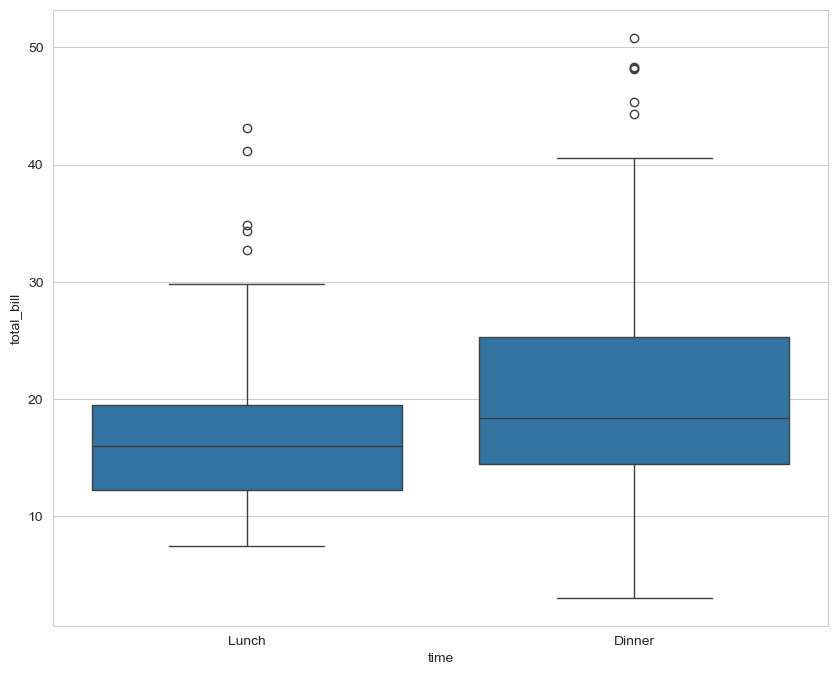

In [35]:
tips = sns.load_dataset('tips')
plt.figure(figsize=[10, 8], dpi=100)
sns.boxplot(data=tips, x='time', y='total_bill')
plt.show()

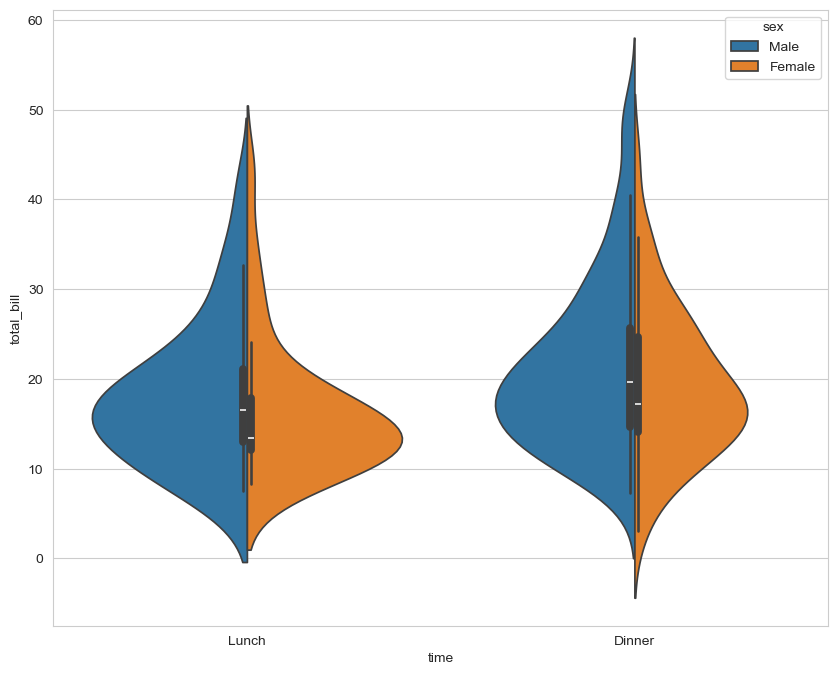

In [36]:
plt.figure(figsize=[10, 8], dpi=100)
sns.violinplot(data=tips, x='time', y='total_bill', hue='sex', split=True)
plt.show()